In [1]:
2+2

4

In [2]:
import sys
import pandas
import matplotlib
import seaborn
import sklearn

print(sys.version)
print(pandas.__version__)
print(matplotlib.__version__)
print(seaborn.__version__)
print(sklearn.__version__)

3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
2.3.3
3.10.8
0.13.2
1.7.2


In [3]:
!pip install seaborn

In [4]:
import sys
import pandas
import matplotlib
import seaborn
import sklearn

print(sys.version)
print(pandas.__version__)
print(matplotlib.__version__)
print(seaborn.__version__)
print(sklearn.__version__)

3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]
2.3.3
3.10.8
0.13.2
1.7.2


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [6]:
# load the data
games = pandas.read_csv("games.csv")

In [7]:
#print top five rows
games.head()

,id,type,name,yearpublished,minplayers,maxplayers,playingtime,minplaytime,maxplaytime,minage,users_rated,average_rating,bayes_average_rating,total_owners,total_traders,total_wanters,total_wishers,total_comments,total_weights,average_weight
0,12333,boardgame,Twilight Struggle,2005.0,2.0,2.0,180.0,180.0,180.0,13.0,20113,8.33774,8.22186,26647,372,1219,5865,5347,2562,3.4785
1,120677,boardgame,Terra Mystica,2012.0,2.0,5.0,150.0,60.0,150.0,12.0,14383,8.28798,8.14232,16519,132,1586,6277,2526,1423,3.8939
2,102794,boardgame,Caverna: The Cave Farmers,2013.0,1.0,7.0,210.0,30.0,210.0,12.0,9262,8.28994,8.06886,12230,99,1476,5600,1700,777,3.7761
3,25613,boardgame,Through the Ages: A Story of Civilization,2006.0,2.0,4.0,240.0,240.0,240.0,12.0,13294,8.20407,8.05804,14343,362,1084,5075,3378,1642,4.1590
4,3076,boardgame,Puerto Rico,2002.0,2.0,5.0,150.0,90.0,150.0,12.0,39883,8.14261,8.04524,44362,795,861,5414,9173,5213,3.2943


In [8]:
# Print the names of the columns in games
print(games.columns)

#Print the shape of the games data
print(games.shape)

Index(['id', 'type', 'name', 'yearpublished', 'minplayers', 'maxplayers',
       'playingtime', 'minplaytime', 'maxplaytime', 'minage', 'users_rated',
       'average_rating', 'bayes_average_rating', 'total_owners',
       'total_traders', 'total_wanters', 'total_wishers', 'total_comments',
       'total_weights', 'average_weight'],
      dtype='object')
(81312, 20)


In [9]:
# Descriptive statistics for each column
games.describe()


,id,yearpublished,minplayers,maxplayers,playingtime,minplaytime,maxplaytime,minage,users_rated,average_rating,bayes_average_rating,total_owners,total_traders,total_wanters,total_wishers,total_comments,total_weights,average_weight
count,81312.000000,81309.000000,81309.000000,81309.000000,81309.000000,81309.000000,81309.000000,81309.000000,81312.000000,81312.000000,81312.000000,81312.000000,81312.000000,81312.000000,81312.000000,81312.000000,81312.000000,81312.000000
mean,72278.150138,1806.630668,1.992018,5.637703,51.634788,49.276833,51.634788,6.983975,161.886585,4.212144,1.157632,262.502509,9.236423,12.688890,42.719144,49.290031,16.488009,0.908083
std,58818.237742,588.517834,0.931034,56.076890,345.699969,334.483934,345.699969,5.035138,1145.978126,3.056551,2.340033,1504.536693,39.757408,60.764207,239.292628,284.862853,115.980285,1.176002
min,1.000000,-3500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,21339.750000,1984.000000,2.000000,2.000000,8.000000,10.000000,8.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,43258.000000,2003.000000,2.000000,4.000000,30.000000,30.000000,30.000000,8.000000,2.000000,5.265620,0.000000,7.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
75%,128836.500000,2010.000000,2.000000,6.000000,60.000000,60.000000,60.000000,12.000000,16.000000,6.718777,0.000000,51.000000,2.000000,3.000000,7.000000,9.000000,2.000000,1.916700
max,184451.000000,2018.000000,99.000000,11299.000000,60120.000000,60120.000000,60120.000000,120.000000,53680.000000,10.000000,8.221860,73188.000000,1395.000000,1586.000000,6402.000000,11798.000000,5996.000000,5.000000


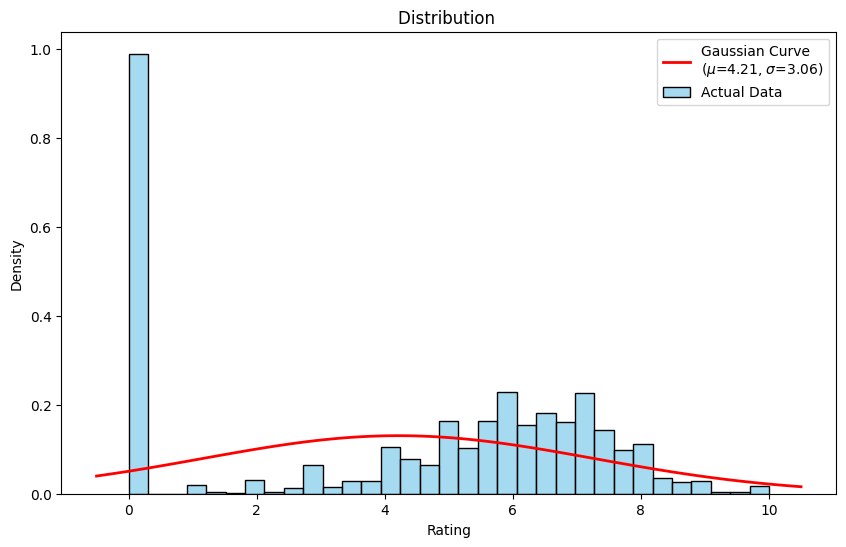

In [12]:
from scipy.stats import norm
import numpy as np

# 2. Calculate the mean and standard deviation
data = games["average_rating"]
mu, std = data.mean(), data.std()

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot the histogram (Density=True scales it so the curve fits)
sns.histplot(data, kde=False, stat="density", color='skyblue', label='Actual Data')

# 4. Calculate the Bell Curve (Gaussian)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# 5. Overlay the Curve
plt.plot(x, p, 'r', linewidth=2, label=f'Gaussian Curve\n($\mu$={mu:.2f}, $\sigma$={std:.2f})')


plt.title(f'Distribution ')
plt.xlabel('Rating')
plt.ylabel('Density')
plt.legend()
plt.show()

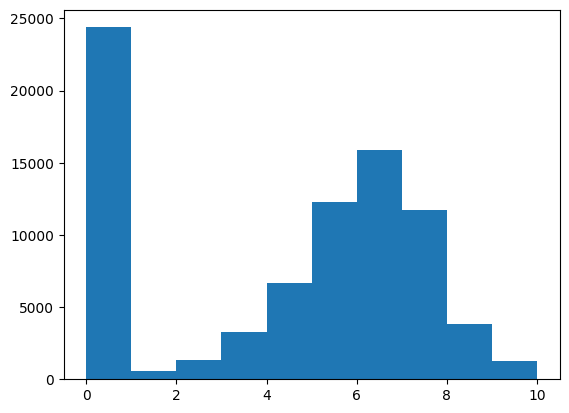

In [13]:
# Make a histogram of all the ratings in the average_rating column
plt.hist(games["average_rating"])
plt.show()

In [14]:
# print the number of rows of all the games with zero average rating scores
print(games[games["average_rating"]==0].shape)

(24380, 20)


In [15]:
# print the number of rows of all the games with non-zero average rating scores
print(games[games["average_rating"]>0].shape)

(56932, 20)


In [16]:
# print the first row of all the games with zero scores
print(games[games["average_rating"]==0].iloc[0])

id                             318
type                     boardgame
name                    Looney Leo
yearpublished                  0.0
minplayers                     0.0
maxplayers                     0.0
playingtime                    0.0
minplaytime                    0.0
maxplaytime                    0.0
minage                         0.0
users_rated                      0
average_rating                 0.0
bayes_average_rating           0.0
total_owners                     0
total_traders                    0
total_wanters                    0
total_wishers                    1
total_comments                   0
total_weights                    0
average_weight                 0.0
Name: 13048, dtype: object


In [17]:
# print the first row of all the games with scores greater then 0
print(games[games["average_rating"]>0].iloc[0])

id                                  12333
type                            boardgame
name                    Twilight Struggle
yearpublished                      2005.0
minplayers                            2.0
maxplayers                            2.0
playingtime                         180.0
minplaytime                         180.0
maxplaytime                         180.0
minage                               13.0
users_rated                         20113
average_rating                    8.33774
bayes_average_rating              8.22186
total_owners                        26647
total_traders                         372
total_wanters                        1219
total_wishers                        5865
total_comments                       5347
total_weights                        2562
average_weight                     3.4785
Name: 0, dtype: object


In [18]:
# Remove any rows without user reviews
games = games[games["users_rated"]>0]

In [19]:
# Remove any rows with missing values
games = games.dropna(axis=0)

In [20]:
# Check the new spread of your cleaned data
games.describe()

,id,yearpublished,minplayers,maxplayers,playingtime,minplaytime,maxplaytime,minage,users_rated,average_rating,bayes_average_rating,total_owners,total_traders,total_wanters,total_wishers,total_comments,total_weights,average_weight
count,56894.000000,56894.000000,56894.000000,56894.000000,56894.000000,56894.000000,56894.000000,56894.000000,56894.000000,56894.000000,56894.000000,56894.000000,56894.000000,56894.000000,56894.000000,56894.000000,56894.000000,56894.000000
mean,64092.223943,1874.793089,2.004834,5.572837,59.921503,57.457184,59.921503,7.591556,231.360477,6.016113,1.654372,374.507470,13.166432,18.002689,60.579024,70.344219,23.548722,1.269716
std,57513.253779,486.032042,0.791475,50.773395,406.451917,393.197450,406.451917,4.869533,1364.124459,1.578830,2.646445,1787.003768,46.984706,71.984315,284.161400,338.375579,138.053005,1.213841
min,1.000000,-3500.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,16133.250000,1989.000000,2.000000,2.000000,15.000000,15.000000,15.000000,4.000000,2.000000,5.000000,0.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
50%,36921.000000,2005.000000,2.000000,4.000000,30.000000,30.000000,30.000000,8.000000,7.000000,6.150000,0.000000,20.000000,1.000000,1.000000,3.000000,4.000000,1.000000,1.000000
75%,118558.750000,2011.000000,2.000000,6.000000,60.000000,60.000000,60.000000,12.000000,39.000000,7.040000,5.488240,125.000000,6.000000,6.000000,15.000000,19.000000,5.000000,2.000000
max,184260.000000,2017.000000,40.000000,11299.000000,60120.000000,60120.000000,60120.000000,120.000000,53680.000000,10.000000,8.221860,73188.000000,1395.000000,1586.000000,6402.000000,11798.000000,5996.000000,5.000000


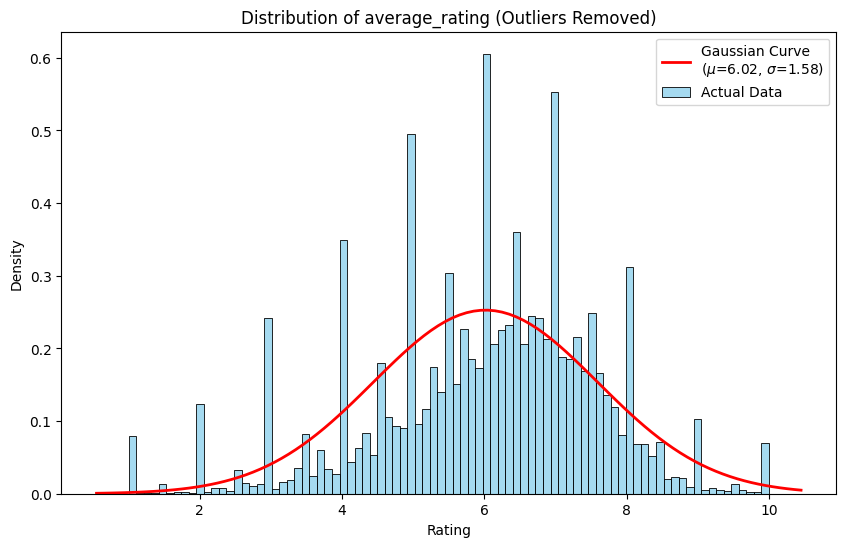

In [21]:
import numpy as np
from scipy.stats import norm
# 1. Pick the column you want to check (e.g., 'average_rating')
column = 'average_rating'
data = games[column].dropna() # Ensure no missing values

# 2. Calculate the mean and standard deviation
mu, std = data.mean(), data.std()

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot the histogram (Density=True scales it so the curve fits)
sns.histplot(data, kde=False, stat="density", color='skyblue', label='Actual Data')

# 4. Calculate the Bell Curve (Gaussian)
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

# 5. Overlay the Curve
plt.plot(x, p, 'r', linewidth=2, label=f'Gaussian Curve\n($\mu$={mu:.2f}, $\sigma$={std:.2f})')


plt.title(f'Distribution of {column} (Outliers Removed)')
plt.xlabel('Rating')
plt.ylabel('Density')
plt.legend()
plt.savefig("my_gaussian_plot.png", dpi=300, bbox_inches='tight')
plt.show()

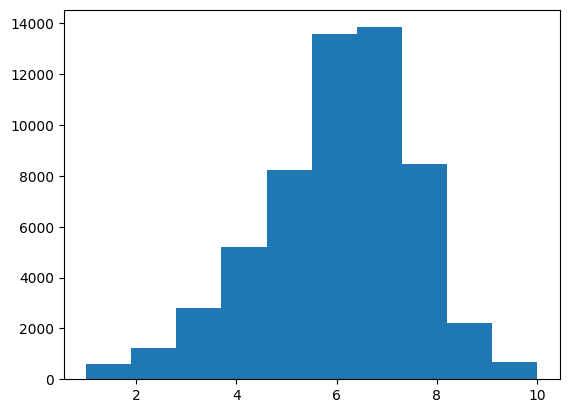

In [22]:
# Make a histogram of all the average ratings
plt.hist(games["average_rating"])
plt.show()

In [ ]:
print(games.columns)

In [23]:
# Correlation Matrix (Creating Correlation Matrix to find out the inter dependencies within different features(attributes))
corrmat = games.corr()
fig = plt.figure(figsize = (12, 9))

sns.heatmap(corrmat, vmax = .8, square = True)
plt.show()


ValueError: could not convert string to float: 'boardgame'

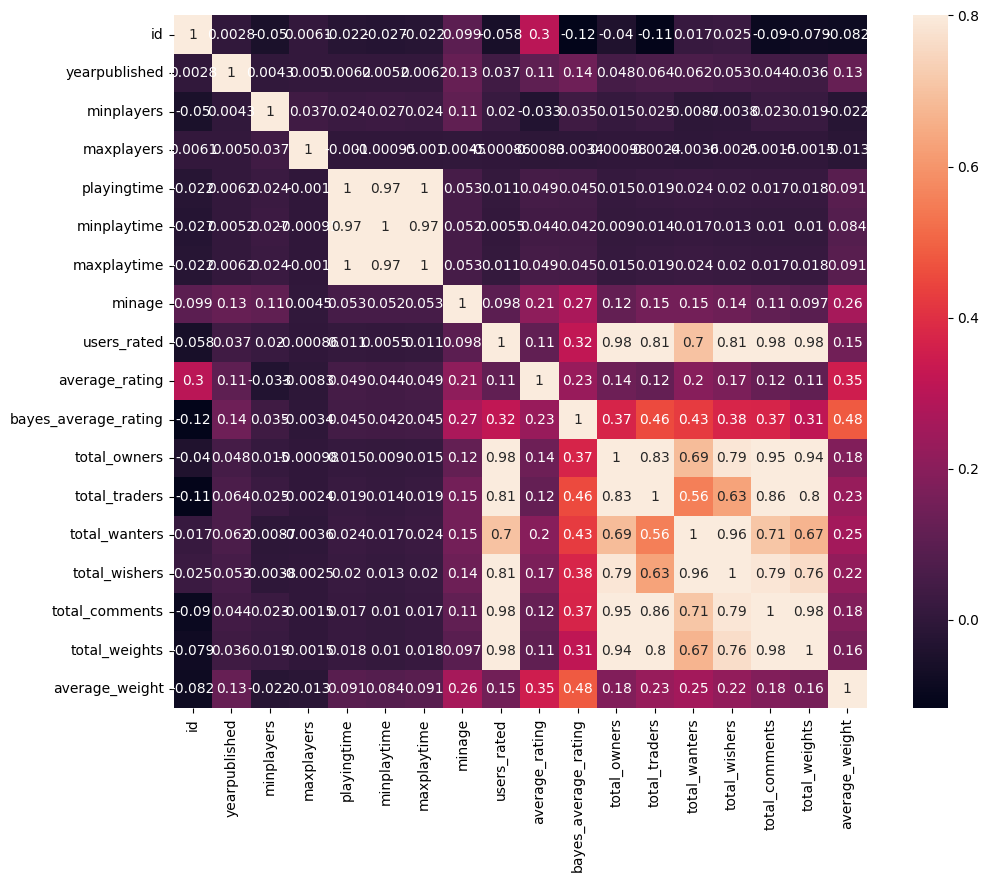

In [24]:
# The 'numeric_only' parameter tells pandas to skip the text columns
corrmat = games.corr(numeric_only=True)

# Now the rest of your code will work!
fig = plt.figure(figsize = (12, 9))
sns.heatmap(corrmat, vmax = .8, square = True, annot=True) # Added annot=True to see the numbers
plt.show()

In [25]:
#  Get all the columns from the dataframe
# Removing the attributes form the games dataset that, 
# we don't want like byes_average_rating, average_rating (this is the target value), type, name and id.

columns = games.columns.tolist()

#filter the columns in the remove data we do not want
columns = [c for c in columns if c not in ["bayes_average_rating", "average_rating", "type", "name", "id"]]

#store the variable  we will be predicting on

target = "average_rating"

Training and Testing Sets
In this final step of data preparation: splitting data into training and testing sets. During training, we let the model ‘see’ the answers, in this case the Average Rating, so it can learn how to predict the Average Rating from the features. We expect there to be some relationship between all the features and the target value, and the model’s job is to learn this relationship during training. Then, when it comes time to evaluate the model, we ask it to make predictions on a testing set where it only has access to the features (not the answers)! Because we do have the actual answers for the test set, we can compare these predictions to the true value to judge how accurate the model is. Generally, when training a model, we randomly split the data into training and testing sets to get a representation of all data points (if we trained on the first 80% games data of the dataset and then used the final 20% games data for prediction.

We can look at the shape of all the data to make sure we did everything correctly. We expect the training features number of columns to match the testing feature number of columns and the number of rows to match for the respective training and testing features :

In [26]:
# Generate training and test datasets
from sklearn.model_selection import train_test_split

# Generate training set
train = games.sample(frac = 0.7, random_state = 1)

# Select anything not in the training set and put it in test
test = games.loc[~games.index.isin(train.index)]

# Print shape
print(train.shape)
print(test.shape)

(39826, 20)
(17068, 20)


Train a Linear Regression model

After all the work of data preparation, creating and training the model is pretty simple using Scikit-learn. We import the Linear regression model from skicit-learn, instantiate the model, and fit (scikit-learn’s name for training) the model on the training data. This entire process is only 3 lines in scikit-learn!

In [27]:
# Import linear regression model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Initialize the model class
LR = LinearRegression()

#Fit the model the training data
LR.fit(train[columns], train[target])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Make Predictions on the Test Set

Our model has now been trained to learn the relationships between the features and the targets. The next step is figuring out how good the model is! To do this we make predictions on the test features (the model is never allowed to see the test answers). We then compare the predictions to the known answers. When performing regression, we need to make sure to use the mean squared error because we expect some of our answers to be low and some to be high. We are interested in how far away our average prediction is from the actual value so we take the mean squared error.
The below code Generate prediciton for the test set using Linear Regression and Compute error between test predictions and actual values

In [28]:
# Generate prediciton for the test set
predictions = LR.predict(test[columns])

# Compute error between test predictions and actual values
mean_squared_error(predictions, test[target])

2.092609021435106

Train a Random Forest Regressor

As our average estimate above is more than 1 degree ,so to reduce it we try different model Random Forest Regressor model. creating and training the Random Forest Regressor model is pretty simple using Scikit-learn. We import the Random Forest Regression model from skicit-learn, instantiate the model, and fit (scikit-learn’s name for training) the model on the training data. This entire process is only 3 lines in scikit-learn!


In [29]:
# Import the random forest model
from sklearn.ensemble import RandomForestRegressor

# Initialize the model
RFR = RandomForestRegressor(n_estimators = 100, min_samples_leaf=10, random_state = 1)

#Fit to the data
RFR.fit(train[columns], train[target])

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [30]:
# Generate prediciton for the test set
predictions = RFR.predict(test[columns])

# Calculate the absolute errors
error = abs(predictions - test[target])

# Compute error between test predictions and actual values
mean_squared_error(predictions, test[target])

1.467603096453988

Our average estimate is off by 1.445856 degrees. That is more than 1 degree but better than Linear Regressor. Although this might not seem significant better than our prediction with Linear Regressor Model.

Determine Performance Metrics

To put our predictions in perspective, we can calculate an accuracy using the mean average percentage error subtracted from 100%.

In [31]:
import numpy as np

# Calculate mean absolute percentage error (MAPE)
mape = 100 * (error / test[target])

# Calculate and display accuracy
accuracy = 100 - np.mean(mape)
print('Accuracy:', round(accuracy, 2), '%.')

Accuracy: 79.66 %.


That looks pretty good! Our model has learned how to predict the average rating with 79.79% accuracy.

Compare predictions Generated by LR and RFR

Here comparing predictions generated by LR and RFR for a first test row

In [32]:
test[columns].iloc[0]

yearpublished      2012.0000
minplayers            2.0000
maxplayers            5.0000
playingtime         150.0000
minplaytime          60.0000
maxplaytime         150.0000
minage               12.0000
users_rated       14383.0000
total_owners      16519.0000
total_traders       132.0000
total_wanters      1586.0000
total_wishers      6277.0000
total_comments     2526.0000
total_weights      1423.0000
average_weight        3.8939
Name: 1, dtype: float64

In [33]:
# Make pridictions iwth both models
rating_LR = LR.predict(test[columns].iloc[0].values.reshape(1,-1))
rating_RFR = RFR.predict(test[columns].iloc[0].values.reshape(1,-1))

#print out the predictions
print(rating_LR)
print(rating_RFR)

[10.27979575]
[7.90057114]


C:\Users\Lenovo\miniconda3\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\miniconda3\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [34]:
# Print the actual value
test[target].iloc[0]

np.float64(8.28798)

In [35]:
# Make pridictions iwth both models
rating_LR = LR.predict(test[columns].iloc[1].values.reshape(1,-1))
rating_RFR = RFR.predict(test[columns].iloc[1].values.reshape(1,-1))

#print out the predictions
print(rating_LR)
print(rating_RFR)

[8.11709383]
[7.8918655]


C:\Users\Lenovo\miniconda3\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\Lenovo\miniconda3\envs\ml_env\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [36]:
# Print the actual value
test[target].iloc[1]

np.float64(8.07933)